In [ ]:
# In colab run this cell first to setup the file structure!
%cd /content
!rm -rf MOL518-Intro-to-Data-Analysis

!git clone https://github.com/shaevitz/MOL518-Intro-to-Data-Analysis.git
%cd MOL518-Intro-to-Data-Analysis/Lecture_33

# BPY518 Lecture 33: Image Transformations and Fourier Transforms

## Lecture Outline
- Fourier transforms and spatial frequency
- Low-pass and high-pass filtering
- Affine transformations
- Cropping and resizing
- Decimation and interpolation

In [6]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy import ndimage, interpolate

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

media_dir = Path('media')

## A Short Fourier Transform Review

A Fourier transform represents a signal as a sum of sinusoids with different frequencies. For images, those frequencies describe how rapidly intensity changes across space.

- **Low spatial frequencies** correspond to smooth, slowly varying structure.
- **High spatial frequencies** correspond to sharp edges, fine texture, and rapid oscillations.

Let's review what hapens in one dimension by adding together a slowly-varying and a faster-varying sine wave.

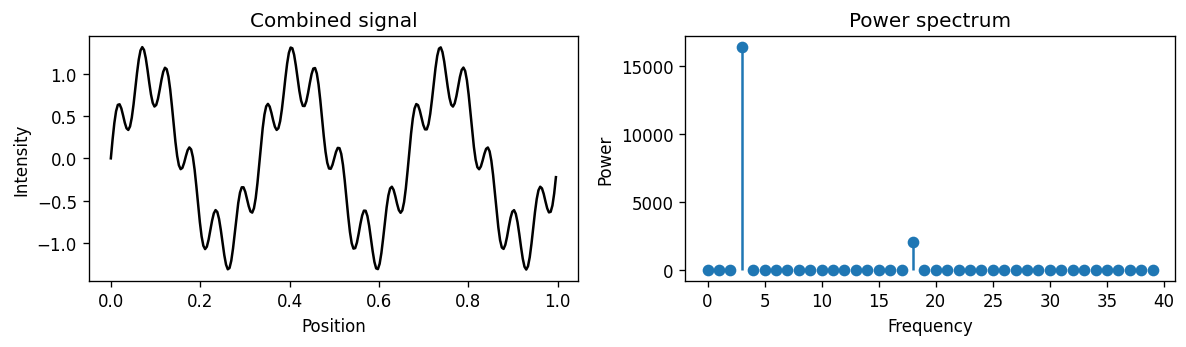

In [7]:
# 1D vector with low- and high-frequency components.
x = np.linspace(0, 1, 256, endpoint=False)
low_component = np.sin(2 * np.pi * 3 * x)
high_component = 0.35 * np.sin(2 * np.pi * 18 * x)
signal = low_component + high_component

fft_signal = np.fft.fft(signal)
frequencies = np.fft.fftfreq(signal.size, d=x[1] - x[0])
power = np.abs(fft_signal) ** 2

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(x, signal, color='black')
axes[0].set_title('Combined signal')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Intensity')

axes[1].stem(frequencies[:40], power[:40], basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[1].set_title('Power spectrum')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Power')

plt.tight_layout()

We can perform a low and high pass filter on the 1D data like this:

Text(0.5, 0, 'Position')

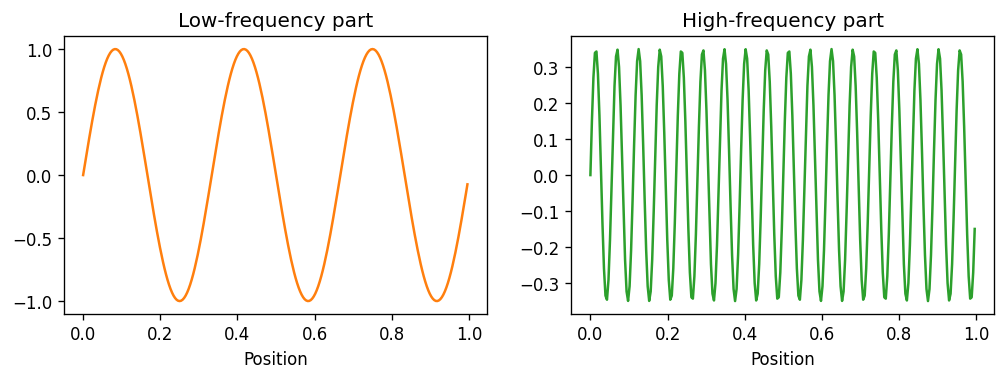

In [8]:
low_mask = np.abs(frequencies) <= 6
high_mask = np.abs(frequencies) >= 10
low_reconstruction = np.fft.ifft(fft_signal * low_mask).real
high_reconstruction = np.fft.ifft(fft_signal * high_mask).real


fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(x, low_reconstruction, color='C1')
axes[0].set_title('Low-frequency part')
axes[0].set_xlabel('Position')

axes[1].plot(x, high_reconstruction, color='C2')
axes[1].set_title('High-frequency part')
axes[1].set_xlabel('Position')

**We can do the fourier transform in two dimensions**

<img src="media/2Dfft_changingF.gif" alt="2D FFT changing frequency" width="80%">

<img src="media/2Dfft_changingDir.gif" alt="2D FFT changing direction" width="80%">

## Filtering images with FFTs

Let's load a microscopy image we saw last semester.

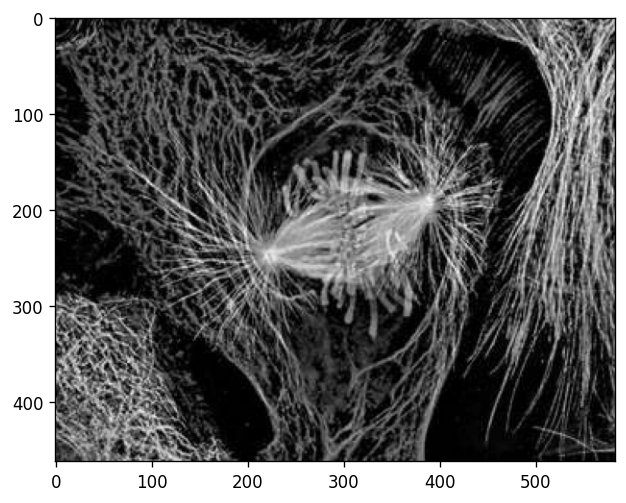

In [9]:
# Load the microscopy example image.
microscopy = mpimg.imread(media_dir / 'microscopy_example.png')
if microscopy.ndim == 3:
    microscopy = microscopy[..., 0]
microscopy = microscopy.astype(float)
if microscopy.max() > 1:
    microscopy /= microscopy.max()
    
plt.imshow(microscopy, cmap='gray');

It's Fourier transform is quite complex. As usual we will display the Power Spectrum (the square of the FT) as it is a real quantity.

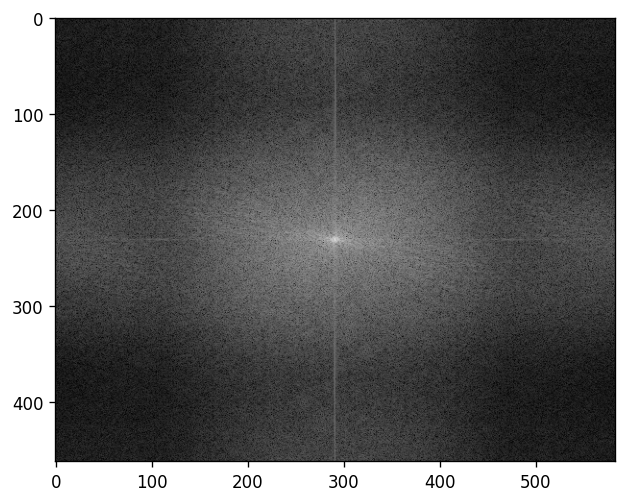

In [10]:
fft2 = np.fft.fftshift(np.fft.fft2(microscopy))
power_spectrum = np.log1p(np.abs(fft2))
plt.imshow(power_spectrum, cmap='gray');

We can filter the image by masking the FT and then performing an inverse Fourier transform (IFFT).

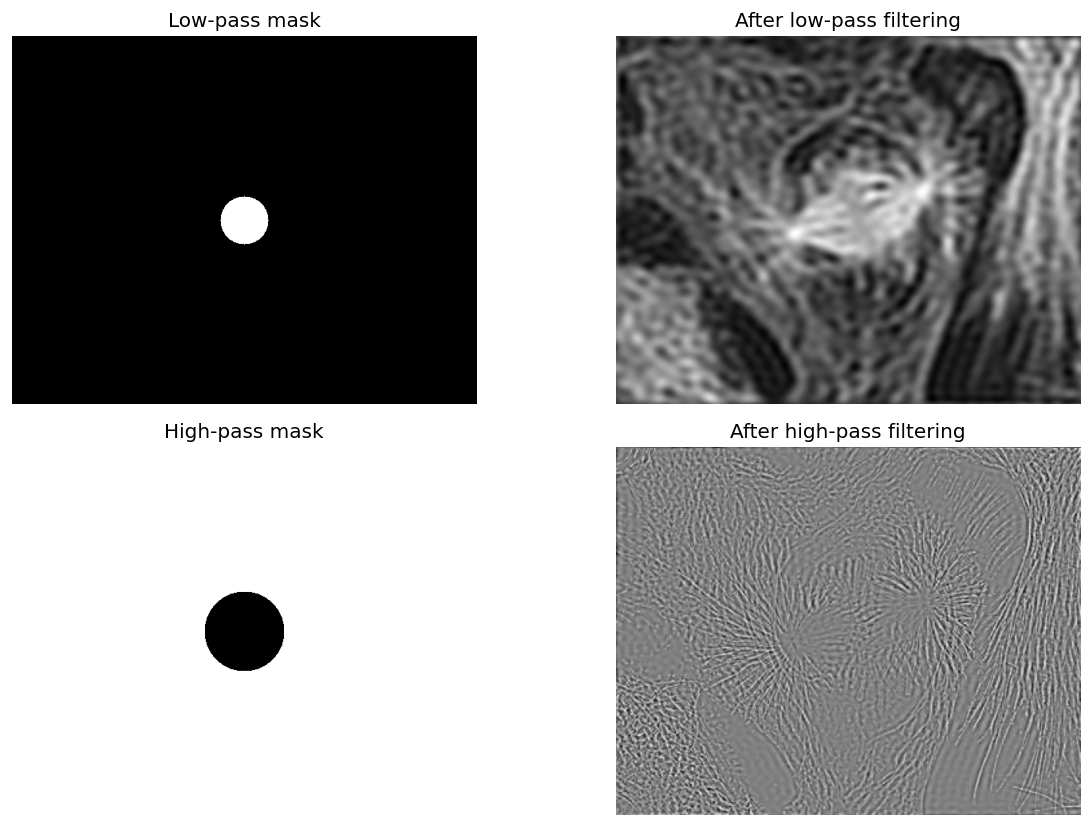

In [11]:
rows, cols = microscopy.shape
yy, xx = np.ogrid[:rows, :cols]
cy, cx = rows // 2, cols // 2
radius = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

low_pass_mask = radius <= 30
high_pass_mask = radius >= 50

low_pass_image = np.fft.ifft2(np.fft.ifftshift(fft2 * low_pass_mask)).real
high_pass_image = np.fft.ifft2(np.fft.ifftshift(fft2 * high_pass_mask)).real

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].imshow(low_pass_mask, cmap='gray')
axes[0, 0].set_title('Low-pass mask')
axes[0, 1].imshow(low_pass_image, cmap='gray')
axes[0, 1].set_title('After low-pass filtering')
axes[1, 0].imshow(high_pass_mask, cmap='gray')
axes[1, 0].set_title('High-pass mask')
axes[1, 1].imshow(high_pass_image, cmap='gray')
axes[1, 1].set_title('After high-pass filtering')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()

### Exercise 1

Use a notch filter in Fourier space to remove one periodic component from the microscopy image.

1. Looking at the FFT Power Spectrum image above, pick one off-center region that has some signal in it.
3. Zero out a small disk around that region (and its symmetric partner). This is called *notch mask*.
4. Reconstruct the image and compare before/after.

Keep your notch small so you remove as little frequency content as possible.

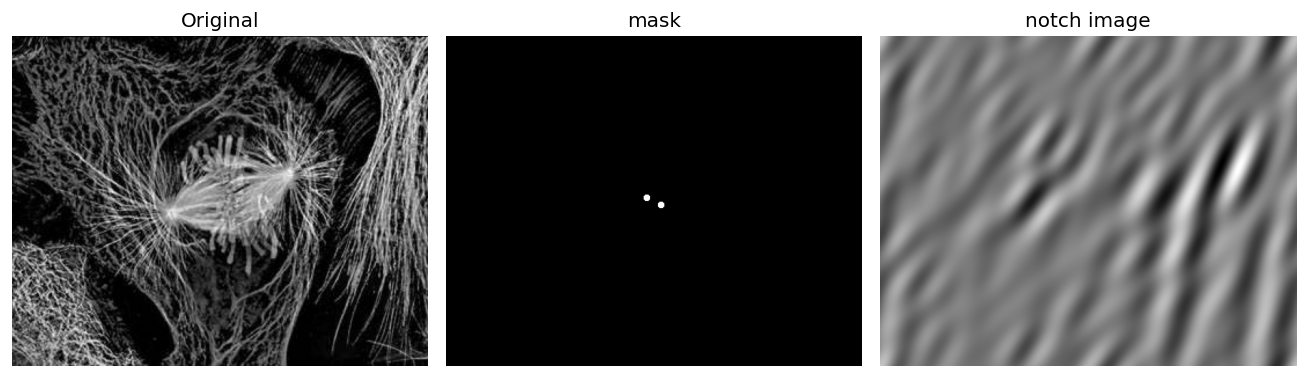

In [26]:
# Your code here
rows, cols = microscopy.shape
yy, xx = np.ogrid[:rows, :cols]
cy, cx = rows // 2, cols // 2
radius = np.sqrt((yy - (cy+5)) ** 2 + (xx - (cx+10)) ** 2)
partner_radius = np.sqrt((yy - (cy-5)) ** 2 + (xx - (cx-10)) ** 2)

mask = (radius >= 5) & (partner_radius >= 5)
mask = ~mask

notch_image = np.fft.ifft2(np.fft.ifftshift(fft2 * mask)).real

fig, axes = plt.subplots(1, 3, figsize=(11, 7))
axes[0].imshow(microscopy, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('mask')
axes[2].imshow(notch_image, cmap='gray')
axes[2].set_title('notch image')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()

## Affine Transformations

An affine transformation changes image coordinates using a linear map plus a translation:

$$
\begin{bmatrix}x' \\ y'\end{bmatrix} =
\mathbf{A}\begin{bmatrix}x \\ y\end{bmatrix} + \mathbf{t}
$$

If we write the matrix and translation components explicitly, this becomes

$$
\begin{bmatrix}x' \\ y'\end{bmatrix} =
\begin{bmatrix}a & b \\ c & d\end{bmatrix}
\begin{bmatrix}x \\ y\end{bmatrix} +
\begin{bmatrix}t_x \\ t_y\end{bmatrix}
$$


Depending on the values in $\mathbf{A}$, this can produce rotations, scalings, shears, or combinations of them. The translation vector $\mathbf{t}$ shifts the image afterward.

![Affine schematic](media/affine_schematic.png)

In code,  image-processing libraries represent the  transform as a $2 \times 3$ matrix:

```python
M = np.float32([
    [a, b, tx],
    [c, d, ty]
])

transformed = cv2.warpAffine(image, M, (width, height))
```

Let's load an image to play with:

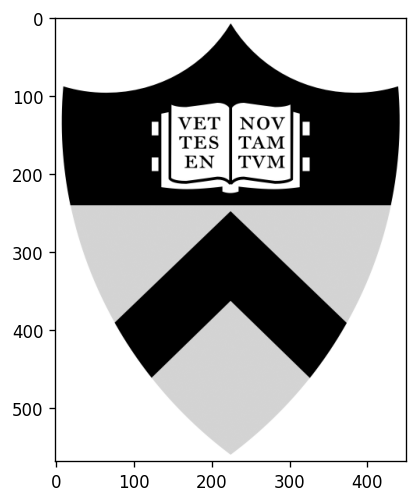

In [7]:
shield = mpimg.imread(media_dir / 'shield_source.png')
if shield.ndim == 3:
    shield = shield[..., 0]
shield = shield.astype(float)
if shield.max() > 1:
    shield /= shield.max()

plt.imshow(shield, cmap='gray');

### Rotation Matrices

The 2x2 rotation block is

$$
R(\theta) =
\begin{bmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
$$

Using this block alone can produce an off-center rotation on an image grid, so we use the OpenCV helper to construct the correct 2x3 affine matrix for rotation about the chosen center: `cv2.getRotationMatrix2D`.

By hand, the unshifted 2x3 form would be:

```python
rotation = np.array([[np.cos(theta), -np.sin(theta), 0],
                     [np.sin(theta),  np.cos(theta), 0]], dtype=np.float32)
```

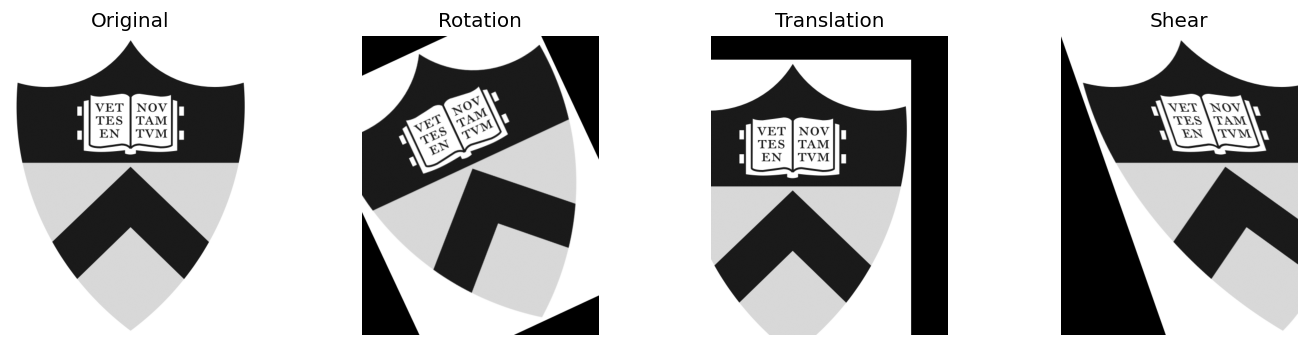

In [8]:
rows, cols = shield.shape
center = np.array([cols / 2, rows / 2], dtype=np.float32)

# Rotation by 25 degrees CCW about the image center
rotation = cv2.getRotationMatrix2D(tuple(center), 25, 1.0)

# Shift the content down 45 and left 70 pixels
translation = np.array([[1, 0, -70.0],
                        [0, 1,  45.0]], dtype=np.float32)

# Horizontal shear with a factor of 0.35
shear = np.array([[1.0, 0.35, 0.0],
                  [0.0, 1.0,  0.0]], dtype=np.float32)

rotated = cv2.warpAffine(shield, rotation, (cols, rows), flags=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_CONSTANT, borderValue=0)
translated = cv2.warpAffine(shield, translation, (cols, rows), flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_CONSTANT, borderValue=0)
sheared = cv2.warpAffine(shield, shear, (cols, rows), flags=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_CONSTANT, borderValue=0)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (title, img) in zip(
    axes,
    [('Original', shield), ('Rotation', rotated),
     ('Translation', translated), ('Shear', sheared)],
):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout();


##  Cropping is just array slicing.

Note, Note the origin is top-left

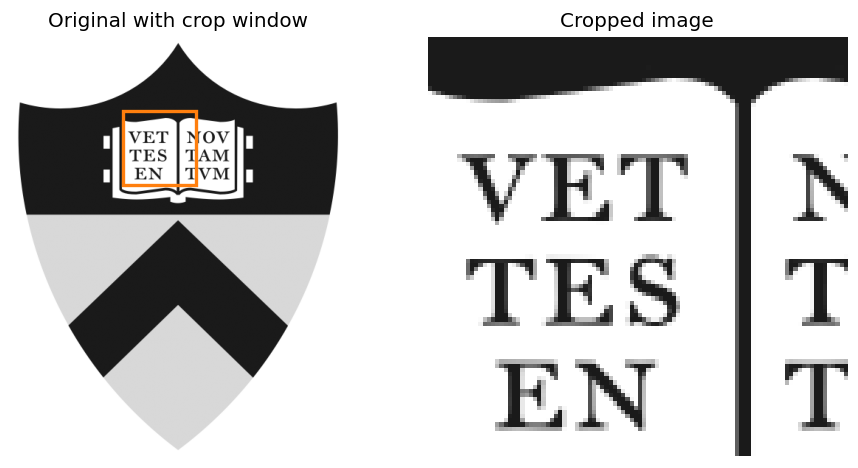

In [29]:
x1, x2 = 150, 250
y1, y2 = 100, 200
cropped_shield = shield[y1:y2, x1:x2]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(shield, cmap='gray', vmin=0, vmax=1)
axes[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='C1', facecolor='none', linewidth=2))
axes[0].set_title('Original with crop window')
axes[0].axis('off')

axes[1].imshow(cropped_shield, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Cropped image')
axes[1].axis('off')

plt.tight_layout()

## Image Resizing, Decimation, and Interpolation

- Reduce memory usage for large images
- Speed up analysis (e.g. segmentation, classification)
- Normalize image sizes across datasets or image stitching
- Increase resolution for visualization or further analysis (is it really resolution?)


Resizing changes the sampling grid of the image.

- **Decimation** keeps every $n$-th pixel and throws the rest away.
- **Interpolation** estimates intensity values at locations that were not originally sampled.

### Decimation

- Reducing image size by discarding pixels
- Risks: aliasing, loss of detail, artifacts
- Good for quick preview, low-res analysis
- Basic Concept: Keep every n-th pixel
- You can decimate by a non-integer amount BUT this involves interpolation...


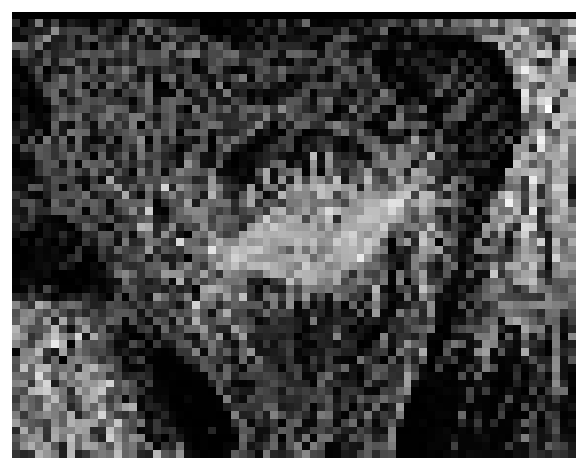

In [14]:
# Decimation by brute force with a for loop

image = microscopy
height, width = image.shape

factor = 8

# Compute new dimensions
new_height = height // factor
new_width = width // factor

# Create a new empty image
decimated = np.zeros((new_height, new_width), dtype=image.dtype)

# Loop through rows and columns
for i in range(new_height):
    for j in range(new_width):
        decimated[i, j] = image[i * factor, j * factor]

plt.figure(figsize=(5, 5))
plt.imshow(decimated, cmap='gray')
plt.axis('off')
plt.tight_layout()

More elegantely, you can do it in one line...
```python
decimated = pattern[::factor, ::factor]
```

**Aliasing**

One thing to look out for is that decimation can lead to *aliasing*, similar to what we saw when discussing structured illumination microscopy. Here is an example.

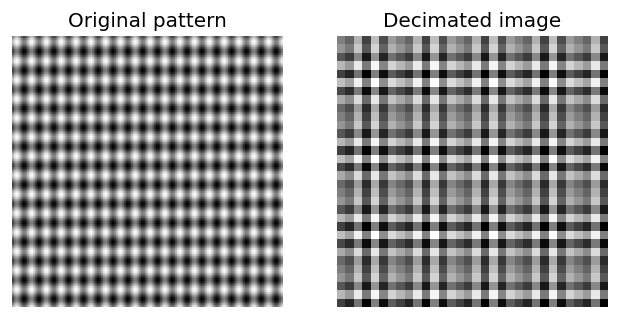

In [19]:

yy, xx = np.mgrid[:128, :128]
pattern = 0.5 + 0.25 * np.sin(2 * np.pi * xx / 7) + 0.25 * np.sin(2 * np.pi * yy / 9)
pattern = np.clip(pattern, 0, 1)

factor = 4
decimated = pattern[::factor, ::factor]

fig, axes = plt.subplots(1, 2)
axes[0].imshow(pattern, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original pattern')
axes[1].imshow(decimated, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Decimated image')

for ax in axes:
    ax.axis('off')

### Interpolation

- When resizing, sometimes new pixel locations don’t align with old ones

- Interpolation involves filling in data between data points (pixels). You obviously don't know what is supposed to be there...

- There are many ways to do this and no right answer. You are making up data that doesn’t exist, user beware!

Let's look at an example in 1D where we use different methods.

- **Nearest Neighbor**: each new x-value takes the value of the closest sample, giving a step-like curve.

- **Linear**: points are connected by straight line segments between neighboring samples.
$$
y = y_a + (y_b - y_a)\frac{x - x_a}{x_b - x_a}
$$

- **Polynomial/Spline**: a smooth curve is fit through the points; it can look natural but *may overshoot between samples*.
$$
f(x) = -0.0001521x^6 - 0.003130x^5 + 0.07321x^4 - 0.3577x^3 + 0.2255x^2 + 0.9038x
$$

![1D interpolation methods](media/1DInterp.png)

Here is an example using a noisy sine wave as the input.

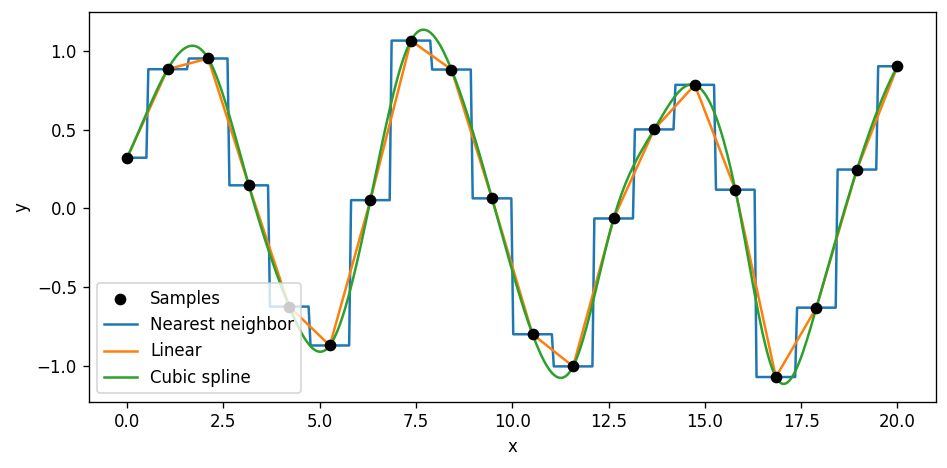

In [ ]:
x_coarse = np.linspace(0, 20, 20)
y_coarse = np.sin(x_coarse) + 0.15 * rng.normal(size=x_coarse.size)
x_dense = np.linspace(x_coarse.min(), x_coarse.max(), 400)

nearest = interpolate.interp1d(x_coarse, y_coarse, kind='nearest')
# Note, interp1d returns a function, so we need to evaluate 
# it at the dense x values to get the interpolated y values.
nearest_values = nearest(x_dense)

linear = interpolate.interp1d(x_coarse, y_coarse, kind='linear')
linear_values = linear(x_dense)

cubic = interpolate.interp1d(x_coarse, y_coarse, kind='cubic')
cubic_values = cubic(x_dense)

plt.figure(figsize=(8, 4))
plt.scatter(x_coarse, y_coarse, color='black', label='Samples', zorder=3)
plt.plot(x_dense, nearest_values, label='Nearest neighbor')
plt.plot(x_dense, linear_values, label='Linear')
plt.plot(x_dense, cubic_values, label='Cubic spline')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()

### Exercise 2

Quantify how much information is lost by decimation and whether interpolation can recover it.

1. Decimate the microscopy of the mitotic cell image by factors 2, 4, and 8.
2. Upsample each decimated image back to the original size with nearest, linear, and cubic interpolation.
3. Compute mean squared error (MSE) relative to the original image.
4. Display MSE values and identify which combination performs best.

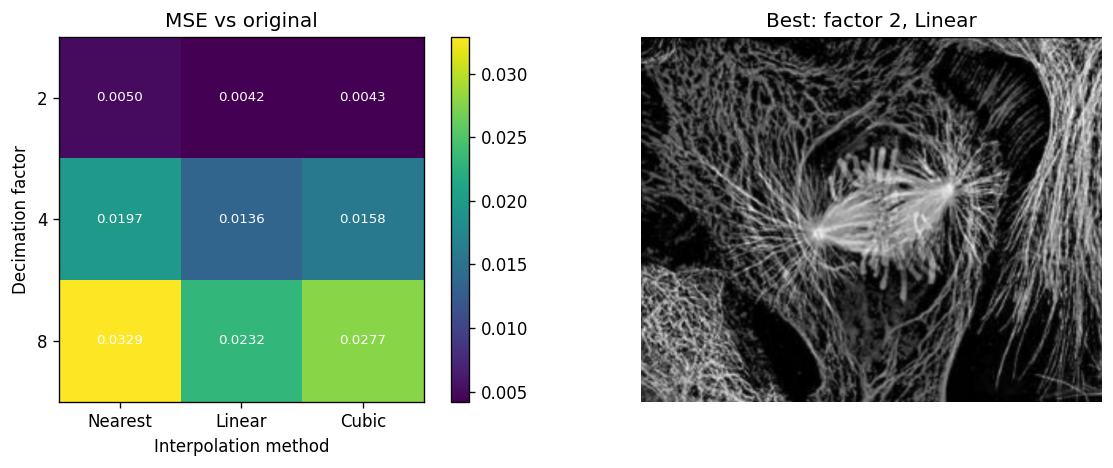

In [ ]:
# Your code here




